# 01 · Análise Exploratória dos Dados

Exploração do corpus EN→PT processado (`data/processed/`), amostrado a partir do OPUS-100 (`Helsinki-NLP/opus-100`, config `en-pt`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from src import config

## Carregando os splits processados

In [2]:
def load_split(name):
    with open(config.DATA_PROCESSED_DIR / f'{name}.en', encoding='utf-8') as f:
        en = [line.strip() for line in f]
    with open(config.DATA_PROCESSED_DIR / f'{name}.pt', encoding='utf-8') as f:
        pt = [line.strip() for line in f]
    return pd.DataFrame({'en': en, 'pt': pt})

df_train = load_split('train')
df_val = load_split('val')
df_test = load_split('test')

print(f'train: {len(df_train):,} pares')
print(f'val:   {len(df_val):,} pares')
print(f'test:  {len(df_test):,} pares')

train: 100,000 pares
val:   1,811 pares
test:  1,811 pares


## Amostra de pares EN→PT

In [3]:
df_train.sample(10, random_state=42)

,en,pt
75721,"Cut him some slack, Don.","Não sejas tão duro com ele, Don."
80184,"Yeah, I did.","Sim, morei."
19864,Have another biscuit.,Mais um biscoito.
76699,Make: …,Marca: …
92991,"Beauties, aren't they?","Está bonito, não?"
76434,Children!,Crianças!
84004,WHAT ARE YOU doing HERE?,- Por que estás aqui?
80917,Dangerous troublemaker.,O encrenqueiro perigoso.
60767,After Lampedusa: ‘How many more?’,Depois de Lampedusa: “Quantos mais?”
50074,This one's top priority.,- Mais duas. Esta aqui tem prioridade.


## Distribuição de tamanho das sentenças (caracteres)

In [4]:
df_train['len_en'] = df_train['en'].str.len()
df_train['len_pt'] = df_train['pt'].str.len()
df_train[['len_en', 'len_pt']].describe()

,len_en,len_pt
count,100000.000000,100000.000000
mean,45.050110,45.224940
std,37.067797,38.579112
min,1.000000,1.000000
25%,20.000000,20.000000
50%,33.000000,32.000000
75%,57.000000,56.000000
max,200.000000,200.000000


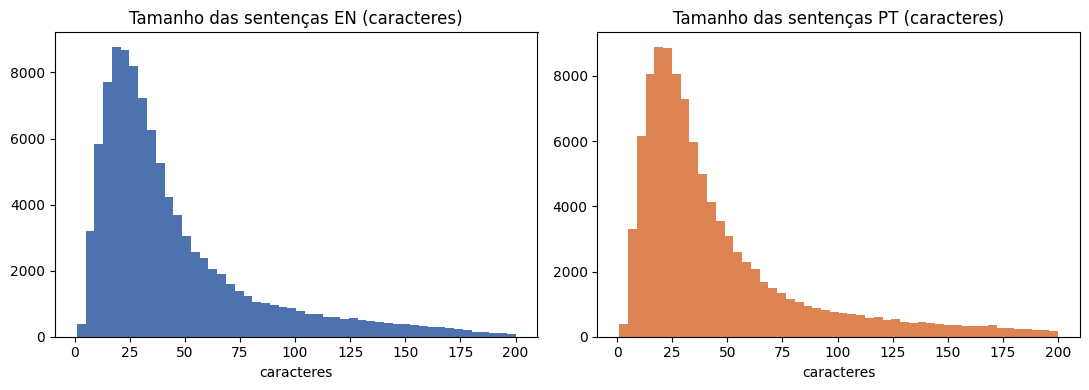

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df_train['len_en'], bins=50, color='#4C72B0')
ax[0].set_title('Tamanho das sentenças EN (caracteres)')
ax[0].set_xlabel('caracteres')
ax[1].hist(df_train['len_pt'], bins=50, color='#DD8452')
ax[1].set_title('Tamanho das sentenças PT (caracteres)')
ax[1].set_xlabel('caracteres')
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'sentence_length_distribution.png', dpi=120)
plt.show()

## Razão de tamanho EN/PT (sanity check do filtro de pré-processamento)

In [6]:
ratio = df_train[['len_en', 'len_pt']].max(axis=1) / df_train[['len_en', 'len_pt']].min(axis=1)
print('razão máxima observada:', ratio.max())
print(f'meta de negócio: pares de treino ~100k -> usados neste projeto: {len(df_train):,}')

razão máxima observada: 2.5
meta de negócio: pares de treino ~100k -> usados neste projeto: 100,000


## Palavras mais frequentes (top 20, após lowercase)


In [7]:
from collections import Counter
import re

def top_words(series, n=20):
    counter = Counter()
    for text in series:
        counter.update(re.findall(r"\w+", text.lower()))
    return counter.most_common(n)

print('EN:', top_words(df_train['en']))
print('PT:', top_words(df_train['pt']))

EN: [('the', 37304), ('you', 24420), ('i', 23843), ('to', 20935), ('of', 17271), ('a', 16559), ('and', 14913), ('s', 12966), ('it', 12809), ('in', 12322), ('that', 11108), ('is', 9878), ('t', 7641), ('we', 7229), ('for', 7002), ('this', 6970), ('on', 5953), ('be', 5541), ('what', 5324), ('me', 5239)]


PT: [('a', 28161), ('de', 28144), ('o', 24672), ('que', 23761), ('não', 15631), ('e', 15070), ('é', 12741), ('um', 9184), ('para', 8928), ('do', 8272), ('uma', 7261), ('se', 7175), ('em', 7011), ('da', 7010), ('com', 6184), ('os', 5884), ('eu', 5376), ('por', 5014), ('me', 4838), ('no', 4789)]
